# ANCOVA — The Case of the Missing Tip Money
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

Welcome back to **Bean & Co.**, the cosiest café on the block.

It's Monday morning. Maria, the manager, is staring at her staff
spreadsheet with a furrowed brow. She has three baristas — **Alex**,
**Bea**, and **Chen** — and at the end of every shift each one drops
their tip jar on the counter. Over the last month she has noticed
something: **Chen always brings home the most tips**. Should she give
Chen a raise? Promote them? Make them barista-of-the-month?

Before she does, our job is to find out: **is Chen actually a better
barista, or did Chen just happen to work the busiest shifts?**

That "or" is exactly what **ANCOVA** (*Analysis of Covariance*) was
invented for. By the end of this notebook, the mystery will be solved
— and you will have a tool you can use whenever a *continuous variable
you didn't control for* is muddying a group comparison.


## Learning Objectives

By the end of this notebook you will be able to:

1. Recognise when a one-way **ANOVA** is misleading because of a
   hidden continuous **covariate**.
2. Set up an **ANCOVA** in `statsmodels` with one categorical factor
   and one (or more) covariates.
3. Compute and interpret **adjusted group means** — what each group's
   outcome would look like if every group had the *same* level of the
   covariate.
4. Read the ANCOVA assumption that often surprises people: the
   **parallel-slopes** (or *homogeneity-of-regression*) assumption.
5. Interpret the regression coefficients of an ANCOVA fit and tie them
   back to the OLS picture from the
   [Linear Regression](LinearRegression.md) and
   [Parameter Estimation](ParameterEstimation.md) notebooks.

*Prerequisite: you've seen one-way ANOVA in the
[ANOVA notebook](ANOVA.md). If not, peek at §3 of that notebook first.*


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(7)


## 1. The Mystery — A Month at Bean & Co.

Maria pulls 30 shifts per barista from her records. Each row tells us:

- which barista worked the shift,
- how many customers walked in (the **covariate** — a number Maria did
  *not* control),
- the total tips collected at the end of the shift (in dollars).

Here's the catch we will pretend Maria hasn't noticed yet: **Chen
tends to be scheduled on the busy weekend shifts**. The data we
synthesise reflects exactly that confound.


In [2]:
n_each = 30

# Each barista has a *true* tip-earning skill (extra dollars per shift
# beyond what the foot traffic explains).
skill = {"Alex": 4.0, "Bea": 5.0, "Chen": 3.0}
# But the schedule is unfair — Chen mostly works busy shifts.
avg_customers = {"Alex": 35, "Bea": 40, "Chen": 70}

rows = []
for b in ["Alex", "Bea", "Chen"]:
    customers = rng.normal(loc=avg_customers[b], scale=8, size=n_each).clip(10, None)
    # Tips = base + 0.40 per customer + barista skill + noise
    tips = 5 + 0.40 * customers + skill[b] + rng.normal(scale=3, size=n_each)
    rows.append(pd.DataFrame({
        "barista":   b,
        "customers": customers.round(0).astype(int),
        "tips":      tips.round(2),
    }))
shifts = pd.concat(rows, ignore_index=True)
shifts.sample(8, random_state=0)


,barista,customers,tips
2,Alex,33,19.19
13,Alex,28,20.25
53,Bea,39,25.38
41,Bea,24,16.92
66,Chen,53,25.05
30,Bea,42,26.58
45,Bea,46,26.33
43,Bea,39,32.42


In [3]:
# A first look — average tips by barista (the number Maria has been staring at)
shifts.groupby("barista")[["tips", "customers"]].mean().round(2)


,tips,customers
barista,,
Alex,21.66,31.73
Bea,25.49,39.40
Chen,34.53,68.47


Chen averages noticeably more tips. **Case closed?** Let's run the
test Maria would naively reach for first.


## 2. The Naive Verdict — One-Way ANOVA

If we ignore the customer counts and just compare tips across
baristas, this is a textbook one-way ANOVA on `tips ~ C(barista)`.


In [4]:
naive = ols("tips ~ C(barista)", data=shifts).fit()
print("Naive one-way ANOVA — tips ~ barista\n")
print(anova_lm(naive))
print("\nGroup-mean offsets (Alex is the baseline):")
print(naive.params.round(2))


Naive one-way ANOVA — tips ~ barista

              df       sum_sq      mean_sq          F        PR(>F)
C(barista)   2.0  2621.491247  1310.745623  84.162407  4.576579e-21
Residual    87.0  1354.938313    15.574004        NaN           NaN

Group-mean offsets (Alex is the baseline):
Intercept             21.66
C(barista)[T.Bea]      3.83
C(barista)[T.Chen]    12.87
dtype: float64


The p-value for `C(barista)` is tiny → "the baristas differ". The
coefficients say Bea earns ~$X more than Alex and Chen earns ~$Y
more than Alex.

Maria is about to print Chen a certificate. **Hold on.** Before we
celebrate, let's look at the picture our naive analysis ignored.


## 3. The Plot Twist — Customer Count Has Been Hiding in Plain Sight

Plot tips against the number of customers, colouring each point by
barista, and the truth jumps off the page:


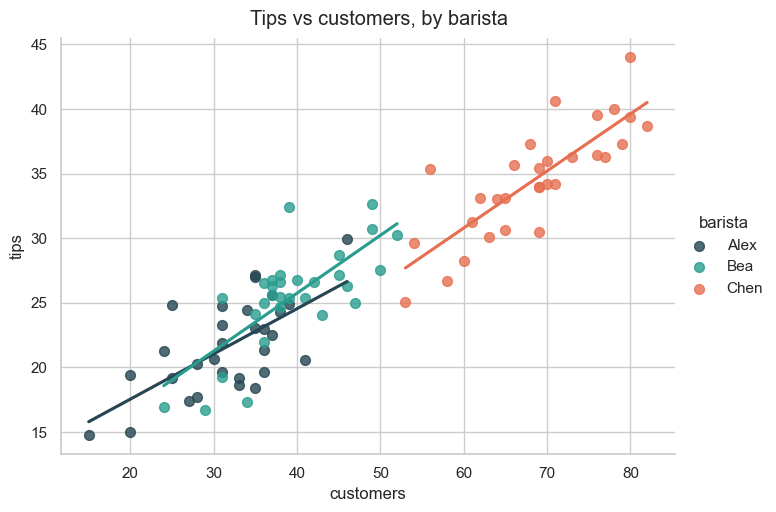

In [5]:
g = sns.lmplot(
    data=shifts, x="customers", y="tips", hue="barista",
    palette=["#264653", "#2a9d8f", "#e76f51"],
    height=5, aspect=1.4, ci=None, scatter_kws={"s": 50, "alpha": 0.8},
)
g.fig.suptitle("Tips vs customers, by barista", y=1.02)
plt.show()


Three things are now obvious:

1. **Tips go up with customer count.** Of course they do — busier
   shifts mean more tippers.
2. **Chen's points are clustered way to the right.** Chen mostly
   worked very busy shifts.
3. **For a given customer count, Chen is not really the highest!**
   Look at any vertical slice (e.g. customers ≈ 50): Bea's line is
   the highest, then Alex, then Chen.

The naive ANOVA didn't see this because it averaged over *all*
customer counts. We need a method that **adjusts for customer count
before comparing baristas**. Enter ANCOVA.


## 4. ANCOVA — ANOVA with a Covariate Sidekick

An ANCOVA is just an ANOVA with one (or more) **continuous
covariates** added to the model:

$$\text{tips} \;=\; \beta_0
\;+\; \beta_1 \cdot \text{customers}
\;+\; \underbrace{\text{barista dummies}}_{\text{Bea, Chen offsets}}
\;+\; \varepsilon.$$

What the covariate does is **soak up the variation in `tips` that
comes from customer count first**, leaving the barista coefficients to
explain only what's left over — the part that really *is* due to who
was behind the bar.

Algorithmically, this is the same `(X^\top X)^{-1} X^\top y` we've been
using all along — we are just adding a column to the design matrix.


In [6]:
ancova = ols("tips ~ customers + C(barista)", data=shifts).fit()
print("ANCOVA — tips ~ customers + C(barista)\n")
print(anova_lm(ancova, typ=2))


ANCOVA — tips ~ customers + C(barista)

                sum_sq    df           F        PR(>F)
C(barista)   44.670593   2.0    3.216638  4.495878e-02
customers   757.782079   1.0  109.132678  5.689204e-17
Residual    597.156234  86.0         NaN           NaN


In [7]:
print("ANCOVA coefficients:")
print(ancova.params.round(2))


ANCOVA coefficients:
Intercept             8.46
C(barista)[T.Bea]     0.64
C(barista)[T.Chen]   -2.41
customers             0.42
dtype: float64


Compare with the naive verdict. Now read the barista coefficients
**holding `customers` constant**:

- `Intercept` — Alex's expected tips when `customers = 0` (a
  hypothetical empty café — useful as a reference, not as a
  prediction).
- `customers` — every extra customer adds about $0.40 in tips,
  *whoever* is working.
- `C(barista)[T.Bea]` — Bea earns this much **more than Alex** at the
  same customer count.
- `C(barista)[T.Chen]` — Chen's bonus relative to Alex at the same
  customer count.

The picture has flipped: **Bea is the most efficient tipper-per-shift,
Alex is in the middle, and Chen is at the bottom** — once you put them
all on the same playing field.


## 5. The "What If They All Had the Same Traffic?" Numbers

ANCOVA gives us a clean way to ask: *if every barista had worked
shifts with the same average number of customers, what would each one
have earned?* These are called **adjusted means** (or *estimated
marginal means*, EMMs).

They're computed by plugging the **overall mean** of `customers` into
the fitted regression for each barista.


In [8]:
mean_customers = shifts["customers"].mean()
print(f"Overall average customers per shift: {mean_customers:.1f}\n")

# Predict tips for each barista at the average customer count
predict_at = pd.DataFrame({
    "customers": [mean_customers] * 3,
    "barista":   ["Alex", "Bea", "Chen"],
})
predict_at["adjusted_tips"] = ancova.predict(predict_at).round(2)
predict_at["raw_mean_tips"] = (
    shifts.groupby("barista")["tips"].mean().reindex(predict_at["barista"]).values.round(2)
)
predict_at


Overall average customers per shift: 46.5



,customers,barista,adjusted_tips,raw_mean_tips
0,46.533333,Alex,27.82,21.66
1,46.533333,Bea,28.45,25.49
2,46.533333,Chen,25.41,34.53


The **raw mean tips** column is what Maria saw in her spreadsheet.
The **adjusted_tips** column is what each barista would earn on a
shift of *typical* busyness. Bea wins on the level playing field, by
a comfortable margin.

**Promotion goes to Bea.** Mystery solved.


## 6. The Picture ANCOVA Draws

ANCOVA fits **one regression line per group, all sharing the same
slope, but with different intercepts**. The vertical gap between the
lines *is* the adjusted group difference.


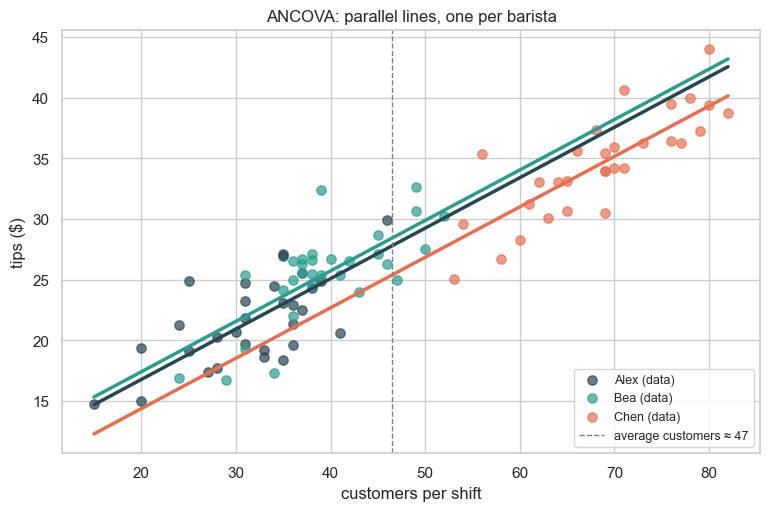

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = {"Alex": "#264653", "Bea": "#2a9d8f", "Chen": "#e76f51"}
x_grid = np.linspace(shifts["customers"].min(),
                     shifts["customers"].max(), 100)

for b in ["Alex", "Bea", "Chen"]:
    sub = shifts[shifts["barista"] == b]
    ax.scatter(sub["customers"], sub["tips"], color=colors[b], s=45,
               alpha=0.7, label=f"{b} (data)")

    # ANCOVA line for this barista — same slope, different intercept
    pred = ancova.predict(pd.DataFrame({"customers": x_grid,
                                        "barista": [b] * len(x_grid)}))
    ax.plot(x_grid, pred, color=colors[b], lw=2.5)

ax.axvline(mean_customers, color="gray", ls="--", lw=1,
           label=f"average customers ≈ {mean_customers:.0f}")
ax.set_xlabel("customers per shift"); ax.set_ylabel("tips ($)")
ax.set_title("ANCOVA: parallel lines, one per barista")
ax.legend(loc="lower right", fontsize=9); plt.show()


Notice the three lines are **parallel**. That parallelism is not a
coincidence — it is *baked into* ANCOVA. The model assumes the
covariate has the same effect (`customers → tips` slope ≈ $0.40 per
customer) for every group.

If that assumption is wrong, ANCOVA is the wrong tool. Let's check it.


## 7. The Assumption Everyone Forgets — Parallel Slopes

ANCOVA inherits the assumptions of ANOVA (independence, residual
normality, homogeneity of variance) **plus one extra**:

> **Homogeneity of regression slopes.** The relationship between the
> covariate and the outcome must be the *same* for every group.

If, say, Chen's tips climb $0.80 per extra customer while Alex's only
climb $0.20, the lines are not parallel and ANCOVA's adjusted means
are misleading.

**The check:** add an interaction term `covariate × group` to the
model. If the interaction is **not significant**, the slopes are close
enough to parallel and ANCOVA is justified. If it *is* significant,
you need a richer model (with the interaction kept in).


In [10]:
# Fit the model WITH the interaction and check whether it's significant
interaction_model = ols("tips ~ customers * C(barista)", data=shifts).fit()
print("Test for parallel slopes — does customers × barista matter?\n")
print(anova_lm(interaction_model, typ=2))


Test for parallel slopes — does customers × barista matter?

                          sum_sq    df           F        PR(>F)
C(barista)             44.670593   2.0    3.185042  4.641874e-02
customers             757.782079   1.0  108.060686  9.437667e-17
customers:C(barista)    8.101167   2.0    0.577618  5.634467e-01
Residual              589.055067  84.0         NaN           NaN


Look at the row `customers:C(barista)`. The p-value is large → no
evidence the slopes differ. We can keep the simpler ANCOVA model.

(If that p-value were small, we'd report results from the interaction
model and not pretend the slopes are parallel.)


## 8. Bonus Round — The Gym Membership Showdown

Three personal trainers — **T1, T2, T3** — claim their training plan
produces the most weight loss after 8 weeks. The catch: clients pick
their own trainer, and the more motivated clients (who already work
out a lot) tend to gravitate to T3. So **starting fitness** confounds
the comparison.

We'll re-run the same ANCOVA pattern.


In [11]:
n_each = 25
trainer_skill = {"T1": 1.5, "T2": 2.5, "T3": 1.0}      # true effect on weight loss (kg)
trainer_fitness_pull = {"T1": 4.0, "T2": 5.0, "T3": 7.5}  # confound

rows = []
for t in ["T1", "T2", "T3"]:
    fitness = rng.normal(loc=trainer_fitness_pull[t], scale=1.0, size=n_each).clip(1, 10)
    weight_loss = 0.5 * fitness + trainer_skill[t] + rng.normal(scale=0.6, size=n_each)
    rows.append(pd.DataFrame({
        "trainer":          t,
        "starting_fitness": fitness.round(1),
        "weight_loss":      weight_loss.round(2),
    }))
gym = pd.concat(rows, ignore_index=True)

print("Naive one-way ANOVA — ignoring fitness:")
print(anova_lm(ols("weight_loss ~ C(trainer)", data=gym).fit()))
print("\nNaive group means (raw):")
print(gym.groupby("trainer")["weight_loss"].mean().round(2))


Naive one-way ANOVA — ignoring fitness:
              df     sum_sq    mean_sq          F        PR(>F)
C(trainer)   2.0  36.817224  18.408612  53.492725  5.788041e-15
Residual    72.0  24.777576   0.344133        NaN           NaN

Naive group means (raw):
trainer
T1    3.37
T2    4.87
T3    4.85
Name: weight_loss, dtype: float64


In [12]:
print("ANCOVA — controlling for starting fitness:\n")
gym_anc = ols("weight_loss ~ starting_fitness + C(trainer)", data=gym).fit()
print(anova_lm(gym_anc, typ=2))

# Adjusted means at average starting fitness
mean_fit = gym["starting_fitness"].mean()
adjusted = pd.DataFrame({
    "starting_fitness": [mean_fit] * 3,
    "trainer":          ["T1", "T2", "T3"],
})
adjusted["adjusted_loss"] = gym_anc.predict(adjusted).round(2)
adjusted["raw_mean_loss"] = (
    gym.groupby("trainer")["weight_loss"].mean().reindex(adjusted["trainer"]).values.round(2)
)
print("\nAdjusted vs raw means at average starting fitness:\n")
print(adjusted)


ANCOVA — controlling for starting fitness:

                     sum_sq    df          F        PR(>F)
C(trainer)        24.549103   2.0  45.504849  1.909701e-13
starting_fitness   5.625921   1.0  20.856704  2.030481e-05
Residual          19.151655  71.0        NaN           NaN

Adjusted vs raw means at average starting fitness:

   starting_fitness trainer  adjusted_loss  raw_mean_loss
0              5.56      T1           3.73           3.37
1              5.56      T2           5.12           4.87
2              5.56      T3           4.24           4.85


Same plot twist as the café: the trainer who *looked* best in the
raw means isn't the one who actually adds the most weight loss once
you put every client on equal footing. Fitness was doing the heavy
lifting.


## 9. Key Takeaways

1. **One-way ANOVA can lie when groups differ on a hidden continuous
   variable.** Whoever drew the lucky shifts will look best.
2. **ANCOVA fixes this** by adding the covariate to the model:
   `outcome ~ covariate + C(group)`. Same `(X^\top X)^{-1} X^\top y`,
   one extra column.
3. **Adjusted means** are the punchline — *what would each group's
   outcome be if every group had the same level of the covariate?*
4. **Geometrically, ANCOVA fits parallel lines** — one per group, all
   sharing the covariate's slope, differing only in their intercepts.
5. The **parallel-slopes assumption** is what makes the picture work.
   Always test it by adding `covariate × group` and checking the
   interaction is not significant.
6. **Use ANCOVA whenever** an obvious confounder is contaminating an
   ANOVA — randomised assignment, observational comparisons, A/B tests
   with imbalanced exposure, anywhere groups didn't start equal.


## 10. Practice Exercises

1. **Promote Chen anyway?** Imagine Maria *halves* Chen's average
   customer count (set `avg_customers["Chen"] = 35`) and re-runs the
   data generation. Re-fit naive ANOVA and ANCOVA. How does the
   ranking of baristas change between the two? Explain in plain words
   what happened.
2. **The slopes really differ.** Modify the café simulation so that
   Chen earns $0.80 per customer (instead of $0.40) but Alex still
   earns $0.40. Run the parallel-slopes test from §7. What does the
   p-value tell you, and what should you report instead of plain
   ANCOVA?
3. **Two covariates at once.** ANCOVA isn't limited to one covariate.
   Add a second one to the gym dataset — say `weeks_since_last_workout`
   — and fit `weight_loss ~ starting_fitness + weeks_since_last_workout
   + C(trainer)`. Do the trainer effects shrink further?
